<a href="https://colab.research.google.com/github/safoolady23-wq/AIN-SA2-PartB/blob/main/AIN_SA2_PartB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
import os
import string
import nltk
import matplotlib.pyplot as plt
from collections import Counter
nltk.download('stopwords')
nltk.download('punk')
import pandas as pd
#from collections import Counter

import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
victorizer = CountVectorizer()
#vator = CountVectorizer.fit_transform(train_x)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
#print(vectors[0])
#pd.read_csv("ship-timber-date.txt")
#pd.read_csv("ai-trainers.txt")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Error loading punk: Package 'punk' not found in index


In [86]:
with open("ship-timber-date.txt", "r", encoding="utf-8") as file:
    ship_text = file.read()# opens and read the ship file

with open("ai-trainers.txt", "r", encoding="utf-8") as file:
    ai_text = file.read() # opens and read the ia files

  # print(ship-timber-date.text[:10])
   #documents = [ship-timber-date.text, ai-trainers.text]
   # print(documents)

In [87]:
import re # Import the regular expression module

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

documents = [ship_text, ai_text]
cleaned_text = [clean_text(doc) for doc in documents]

In [88]:
vectorizer = CountVectorizer(max_features = 100)
vectors = vectorizer.fit_transform(cleaned_text)

feature_names = vectorizer.get_feature_names_out()
print(feature_names)

['added' 'ai' 'allows' 'also' 'analysis' 'another' 'anything' 'apps'
 'archaeologists' 'archaeology' 'back' 'bean' 'better' 'bhanot' 'bn'
 'built' 'century' 'conservation' 'date' 'dating' 'david' 'days'
 'dendrochronology' 'dr' 'drying' 'early' 'every' 'experts' 'feedback'
 'fitness' 'focus' 'found' 'get' 'great' 'gym' 'help' 'historians' 'human'
 'isotope' 'jones' 'know' 'largest' 'like' 'lot' 'magic' 'mary' 'mr' 'new'
 'newport' 'oak' 'old' 'one' 'oxygen' 'people' 'personal' 'process' 'put'
 'really' 'replace' 'research' 'ring' 'river' 'rose' 'said' 'says'
 'screen' 'ship' 'still' 'th' 'thought' 'timber' 'timbers' 'time'
 'together' 'tonne' 'track' 'trainer' 'trainers' 'training' 'tree' 'trees'
 'trinity' 'trying' 'university' 'us' 'use' 'using' 'usk' 'value' 'vessel'
 'want' 'weight' 'wood' 'work' 'working' 'workouts' 'world' 'would' 'year'
 'years']


In [89]:
lda = LatentDirichletAllocation(n_components=10, random_state=42)
lda.fit(vectors)

feature_names = vectorizer.get_feature_names_out()

In [90]:
import numpy as np

def get_top_words(doc_index, X, feature_names, top_n=10):
    row = X[doc_index].toarray().flatten()

    top_indices = row.argsort()[-top_n:][::-1]
    top_words = [(feature_names[i], row [i]) for i in top_indices]
    return top_words # looks for the top 10 words

In [91]:
def get_top_n_words(tokens, n=None):
    """Return the top n words from the frequency tokens."""
    # returns the top 10 words from  the ship and AI articles
    counter = Counter(tokens)
    return counter.most_common(n)
    ship_top_words = get_top_n_words(ship_tokens,10)
    ai_top10_words = get_top_n_words(ai_tokens, 10)
    print("Top 10 words in ship article:")
    print(ship_top_words)
    print("\nTop 10 words in AI article:")
    print(ai_top10_words)

In [92]:
ship_top = get_top_words(0, vectors, feature_names,10)
ai_top = get_top_words(1, vectors, feature_names,10)

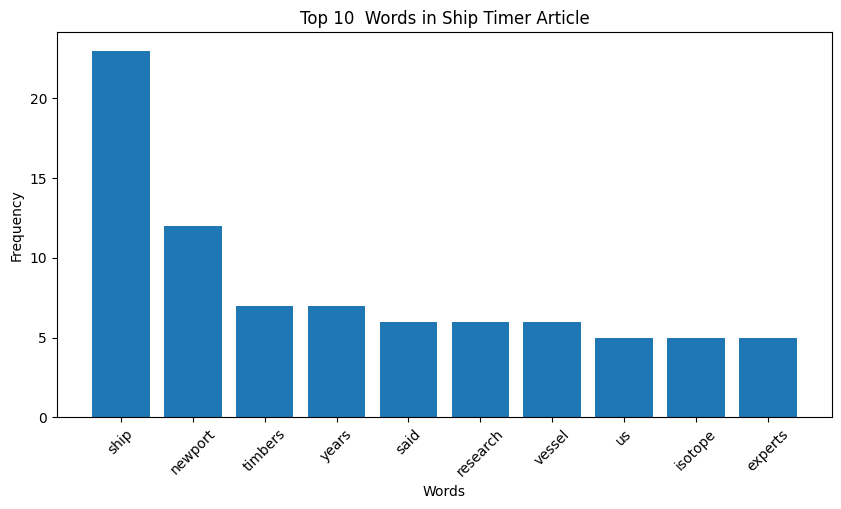

In [93]:
words, counts = zip(*ship_top)

plt.figure(figsize=(10,5)) # the bar grapg is showing the top 10 words in the ship article
plt.bar(words, counts)
plt.title("Top 10  Words in Ship Timer Article")
plt.xticks(rotation=45)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

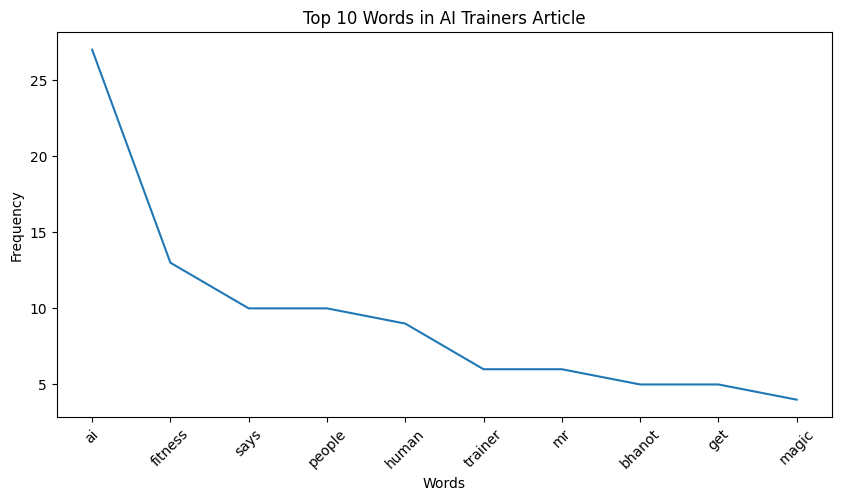

In [94]:
words, counts = zip(*ai_top)

plt.figure(figsize=(10,5))
plt.plot(words, counts) # the plot graph is shoing the top 10 words in the ai article
plt.title("Top 10 Words in AI Trainers Article")
plt.xticks(rotation=45)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()


In [99]:
def get_topic_words(model, feature_names, n_top_words=10):
  topic_data =[]

  for topic_idx, topic in enumerate(model.components_):
    top_indices = topic.argsort()[-n_top_words:][::-1]
    words = [feature_names[i] for i in top_indices]
    weights = [topic[i] for i in top_indices]

    topic_data.append((words, weights))
  # Move return statement outside the loop to gather all topics
  return topic_data

# Call the function with the correct LDA model (lda) and feature_names
topics_3 = get_topic_words(lda, feature_names, 10)

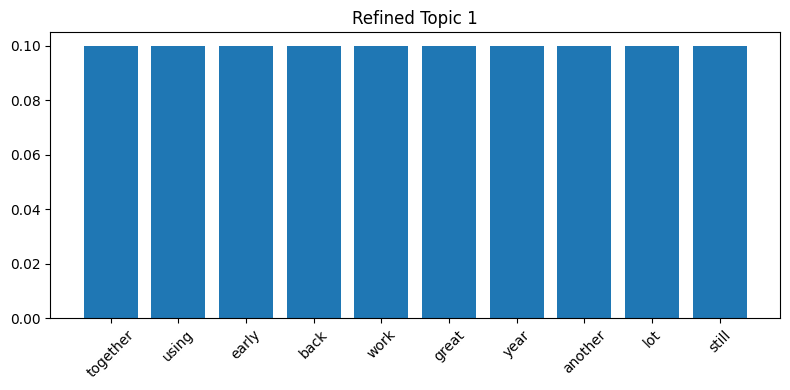

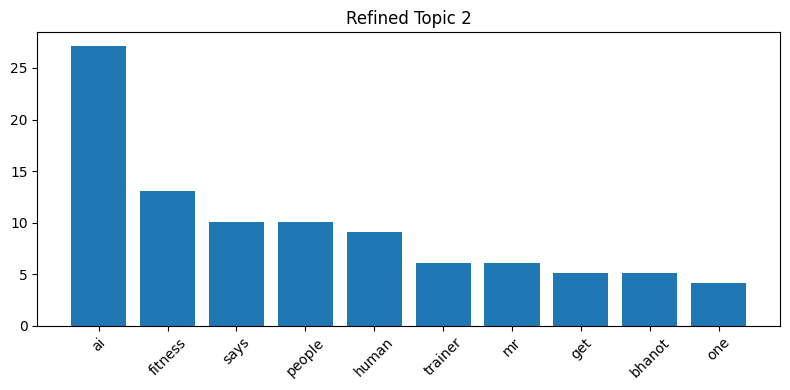

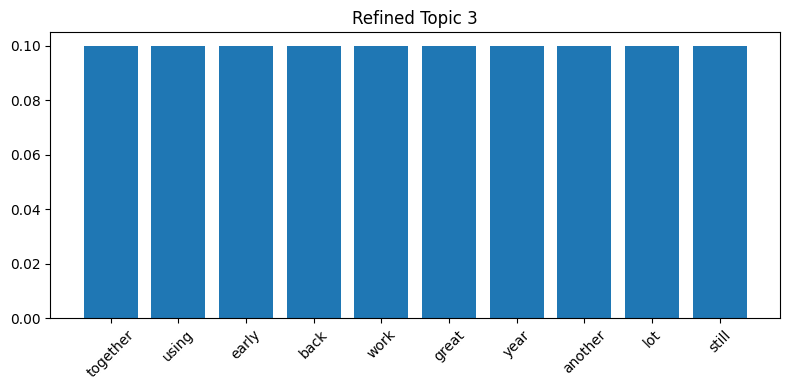

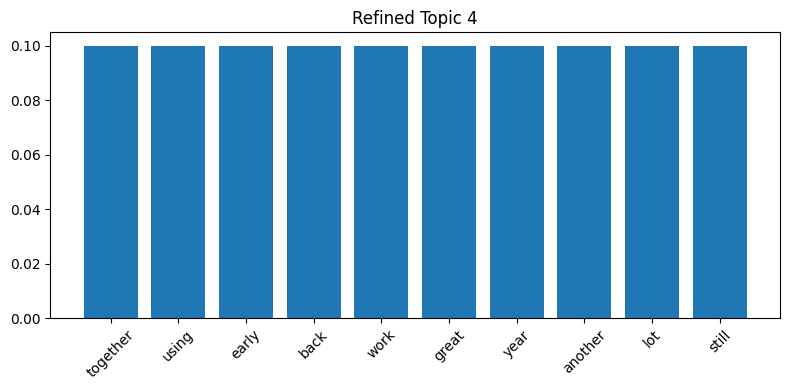

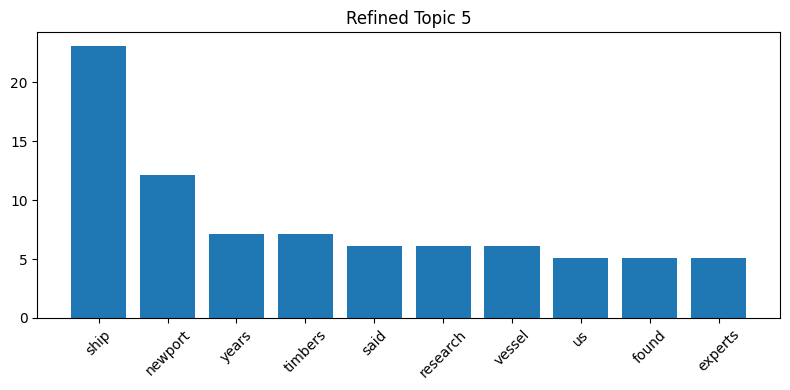

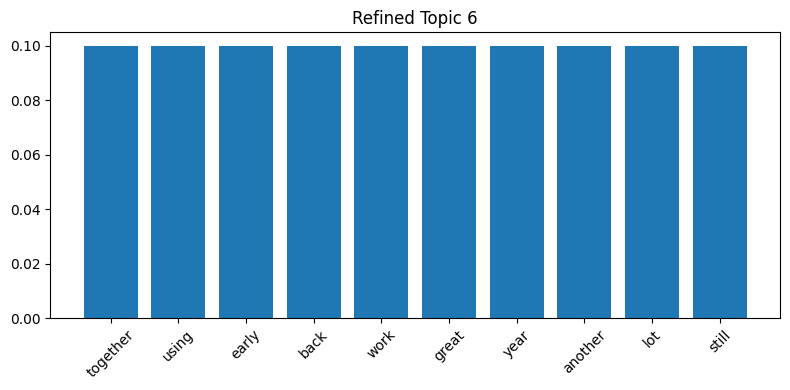

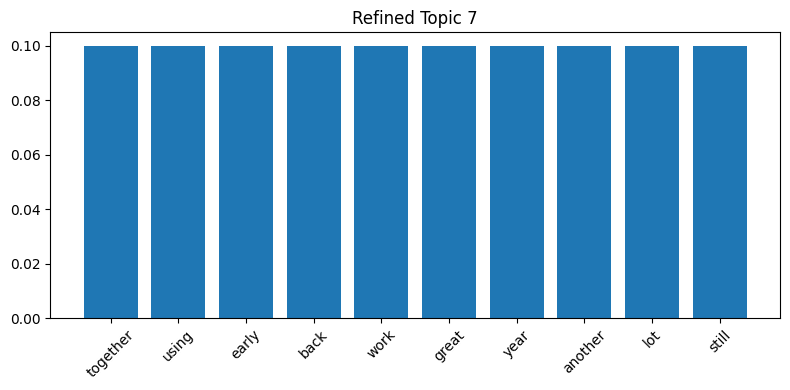

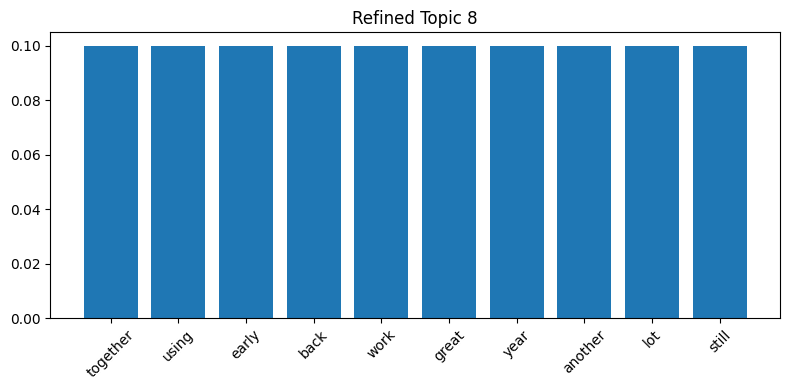

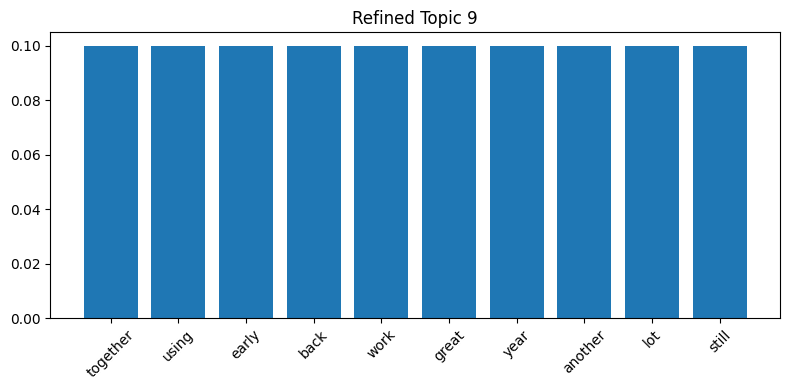

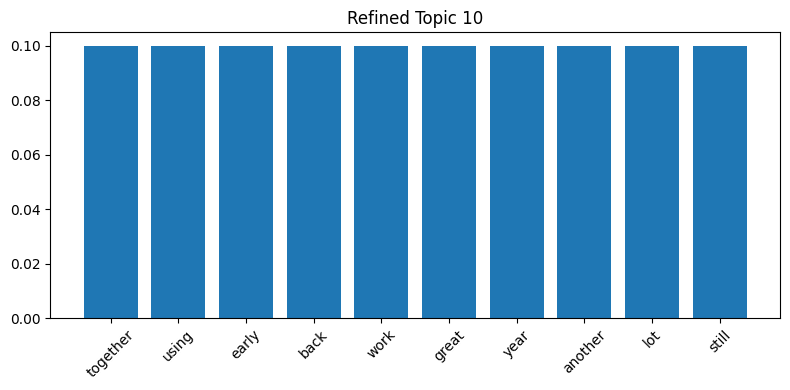

In [100]:
import matplotlib.pyplot as plt

for i, (words, weights) in enumerate(topics_3):
  plt.figure(figsize=(8,4))
  plt.bar(words, weights)
  plt.title(f"Refined Topic {i+1}")
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

In [121]:
doc_topic_dist = lda.transform(vectors)

for i, dist in enumerate(doc_topic_dist):
  print(f"\nArticle {i+1} topic distribution")

  for topic_num, prob in enumerate(dist):
    print(f"Topic {topic_num+1}: {prob:.3f}")

    print(f"Most likely topic: Topic {dist.argmax() +1}")


Article 1 topic distribution
Topic 1: 0.000
Most likely topic: Topic 5
Topic 2: 0.000
Most likely topic: Topic 5
Topic 3: 0.000
Most likely topic: Topic 5
Topic 4: 0.000
Most likely topic: Topic 5
Topic 5: 0.996
Most likely topic: Topic 5
Topic 6: 0.000
Most likely topic: Topic 5
Topic 7: 0.000
Most likely topic: Topic 5
Topic 8: 0.000
Most likely topic: Topic 5
Topic 9: 0.000
Most likely topic: Topic 5
Topic 10: 0.000
Most likely topic: Topic 5

Article 2 topic distribution
Topic 1: 0.001
Most likely topic: Topic 2
Topic 2: 0.995
Most likely topic: Topic 2
Topic 3: 0.001
Most likely topic: Topic 2
Topic 4: 0.001
Most likely topic: Topic 2
Topic 5: 0.001
Most likely topic: Topic 2
Topic 6: 0.001
Most likely topic: Topic 2
Topic 7: 0.001
Most likely topic: Topic 2
Topic 8: 0.001
Most likely topic: Topic 2
Topic 9: 0.001
Most likely topic: Topic 2
Topic 10: 0.001
Most likely topic: Topic 2


In [ ]:
def plot_top_words(top_words, title):
    """Plot a bar chart of the top words."""
    words, counts = zip(*top_words)
    plt.bar(words, counts)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()
    plot_top_words(ship_top_words, "Top Words in Ship Article")
    plot_top_words(ai_top10_words, "Top 10 Words in AI Article")


In [ ]:

try:
    _ = ship_text
except NameError:
    ship_text = "This is dummy text for ship timber data."
    ai_text = "This is dummy text for ai trainers data."

corpus = [ship_text, ai_text]
vectorizer = CountVectorizer(stop_words="english", max_features=50)
X = vectorizer.fit_transform(corpus)
feature_names = vectorizer.get_feature_names_out()

ship_counts = dict(zip(feature_names, X.toarray()[0]))
ai_counts = dict(zip(feature_names, X.toarray()[1]))

def top_n_from_dict(d, n=3):
    return sorted(d.items(), key=lambda x: x[1], reverse=True)[:n]

ship_top_words = top_n_from_dict(ship_counts, n=3)
ai_top_words = top_n_from_dict(ai_counts, n=3)

print("Top 3 words in ship article:")
print(ship_top_words)
print("\nTop 3 words in AI article:")
print(ai_top_words)